# Icechunk Runner and recorders

- Icechunk: git for images.
- Every run, one commit.
- Recorder is optional
- We also have a simple recorder that just outputs json
- The pixi file for this example is beside the notebook
- `pixi run register-kernel`, then kernel **skop (icechunk)**.

## 0. Pick a recorder

- `"none"`: default, records nothing.
- `"text"`: JSON lines, recipe only.
- `"icechunk"`: recipe plus image.

In [ ]:
RECORDER = "text" #"none" | "text" | "icechunk"

## 1. Image on disk

- Start from a file, this is how users will do it.  They may not have a zarr, people with small to medium data still have tifs, so start from there. 

In [5]:
from pathlib import Path

from skimage import data, io

DATA = Path("data")
DATA.mkdir(exist_ok=True)

io.imsave(DATA / "coins.tif", data.coins())
print(sorted(p.name for p in DATA.iterdir()))

['coins.icechunk', 'coins.tif', 'runs.jsonl']


## 2. Open the image

- Icechunk: copy in once.
- Repo is a folder.
- Returns `zarr.Array`.
- Knows its snapshot.
- Otherwise: numpy.

In [6]:
REPO = DATA / "coins.icechunk"

if RECORDER == "icechunk":
    from skop.icechunk_recorder import icechunk_imread

    img = icechunk_imread(DATA / "coins.tif", REPO)
    print(type(img).__name__, img.name, img.shape, img.dtype)
    print(img.store.session.snapshot_id)
else:
    img = io.imread(DATA / "coins.tif")
    print(type(img).__name__, img.shape, img.dtype)

Array /coins (303, 384) uint8
N3FKMKAY9KRFWDFHD860


  2026-10-02T21:35:39.402611Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330

  2026-10-02T21:35:39.426138Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330



- Some skimage fails on Zarr.
- Runner converts to numpy.

In [7]:
type(img)

zarr.core.array.Array

In [8]:
import numpy as np
from skimage.exposure import equalize_hist
from skimage.filters import frangi as sk_frangi

for fn in (equalize_hist, sk_frangi):
    try:
        fn(img)
        print(f"{fn.__name__} works on {type(img).__name__}")
    except AttributeError as e:
        print(f"{fn.__name__} fails on {type(img).__name__}: {e}")

print(f"works on numpy: {equalize_hist(np.asarray(img)).shape}")

equalize_hist fails on Array: 'Array' object has no attribute 'flatten'
frangi fails on Array: 'Array' object has no attribute 'astype'
works on numpy: (303, 384)


## 3. Make the runner

- Plain `skop.Runner`.
- Optional `recorder=`.
- Records in host process.

In [9]:
import skop
from skop.record import TextRecorder

if RECORDER == "icechunk":
    from skop.icechunk_recorder import IcechunkRecorder

    recorder = IcechunkRecorder(REPO)
elif RECORDER == "text":
    recorder = TextRecorder(DATA / "runs.jsonl")
else:
    recorder = None

runner = skop.Runner(recorder=recorder)
print(runner.recorder)

  2026-10-02T21:37:46.384435Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330



## 4. Run an op

- skop `frangi` op.
- Runs in `skimage` env.
- Icechunk returns `zarr.Array`.

Array (303, 384)


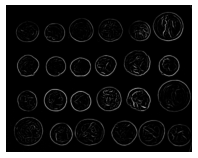

In [10]:
from matplotlib import pyplot as plt

from skop.ops.edges import frangi

plt.rcParams.update({"figure.figsize": (4, 4), "figure.dpi": 60})  # small figures

ridges = runner.run(frangi, image=img)
print(type(ridges).__name__, ridges.shape)

plt.imshow(np.asarray(ridges), cmap="gray")
plt.axis("off");

## 5. Tune a parameter

- One record per run.
- Saved as `frangi`.
- No recorder: empty log.

In [16]:
for sigma in (2.0, 17.0, 18.0):
    runner.run(frangi, image=img, sigma_min=sigma, sigma_max=sigma)

for r in runner.log('frangi'):
    print(r.id[:8], r.message, r.metadata["inputs"])

QP8EXRKT skop.ops.edges:frangi {'sigma_min': 18.0, 'sigma_max': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
CKZMYQAV skop.ops.edges:frangi {'sigma_min': 17.0, 'sigma_max': 17.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
1Z098VSV skop.ops.edges:frangi {'sigma_min': 2.0, 'sigma_max': 2.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
T3FXC73T skop.ops.edges:frangi {'sigma_min': 18.0, 'sigma_max': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
KKXX926Y skop.ops.edges:frangi {'sigma_min': 17.0, 'sigma_max': 17.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
A48H5Y7F skop.ops.edges:frangi {'sigma_min': 2.0, 'sigma_max': 2.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
30Z4H3DN skop.ops.edges:frangi {'sigma_min': 18.0, 'sigma_max': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
J32MW9BY skop.ops.edges:frangi {'sigma_min': 17.0, 'sigma_max': 17.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
V0DC488D skop.ops.edges:frangi {'sigma_min': 2.0, 'sigma_max': 2.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
BWRMPZG4 skop.op

## 6. Pick the best

- You decide, by eye.
- Icechunk only: reopen images.

  2026-10-02T02:42:37.106086Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330

  2026-10-02T02:42:37.111186Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330

  2026-10-02T02:42:37.117333Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330



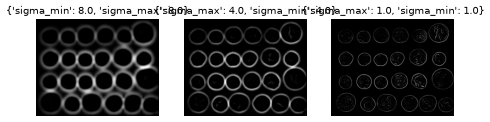

In [8]:
trials = runner.log("frangi")[:3]  # the three runs above, newest first

if RECORDER == "icechunk":
    from skop.icechunk_recorder import icechunk_open

    fig, axes = plt.subplots(1, len(trials), figsize=(3 * len(trials), 3))
    for ax, trial in zip(axes, trials):
        image = icechunk_open(REPO, "frangi", snapshot=trial.id)  # the image from that run
        ax.imshow(np.asarray(image), cmap="gray")
        ax.set_title(str(trial.metadata["params"]))
        ax.axis("off")
elif RECORDER == "text":
    print("simple recorder does not commit results, only parameters")
    for trial in trials:
        print(" ", trial.metadata["params"])
else:
    print("no recorder, nothing to get back")

## 7. Cellpose

- On original coins.
- Own `pytorch` env.
- First call: slow build.
- Logged as `cellpose4`.

In [17]:
from skimage.color import label2rgb

from skop.ops.segment import cellpose4


def show(labels, title):
    plt.figure()
    plt.imshow(label2rgb(np.asarray(labels), np.asarray(img), bg_label=0))
    plt.title(f"{title}: {int(np.asarray(labels).max())} objects")
    plt.axis("off")

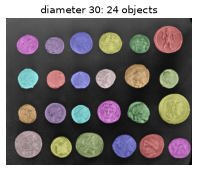

In [18]:
labels_d30 = runner.run(cellpose4, image=img, diameter=30)
show(labels_d30, "diameter 30")

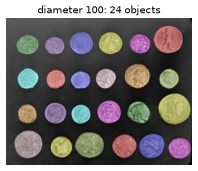

In [19]:
labels_d100 = runner.run(cellpose4, image=img, diameter=100)
show(labels_d100, "diameter 100")

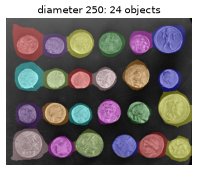

In [20]:
labels_d250 = runner.run(cellpose4, image=img, diameter=250)
show(labels_d250, "diameter 250")

In [22]:
for name in ("frangi", "cellpose"):
    for r in runner.log(name):
        print(f"{name:10} {r.id[:8]} {r.metadata['params']} {r.metadata['inputs']}")

frangi     QP8EXRKT {'sigma_min': 18.0, 'sigma_max': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     CKZMYQAV {'sigma_max': 17.0, 'sigma_min': 17.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     1Z098VSV {'sigma_max': 2.0, 'sigma_min': 2.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     T3FXC73T {'sigma_max': 18.0, 'sigma_min': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     KKXX926Y {'sigma_max': 17.0, 'sigma_min': 17.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     A48H5Y7F {'sigma_max': 2.0, 'sigma_min': 2.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     30Z4H3DN {'sigma_max': 18.0, 'sigma_min': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     J32MW9BY {'sigma_max': 17.0, 'sigma_min': 17.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     V0DC488D {'sigma_min': 2.0, 'sigma_max': 2.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     BWRMPZG4 {'sigma_max': 18.0, 'sigma_min': 18.0} {'image': 'coins@N3FKMKAY9KRFWDFHD860'}
frangi     QMGD3

## 8. Get the best back

- Assume best: diameter 30.
- Find by params.
- No hash typing.
- Then tag it.
- Tags never move.

In [14]:
cp4_results = runner.log("cellpose4")
for r in cp4_results:
    print(r)

Record(id='YRVMP2KAXS0ZF376VN10', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 250}", metadata={'name': 'cellpose4', 'params': {'diameter': 250}, 'op': 'skop.ops.segment.cellpose4:cellpose4', 'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}})
Record(id='70V2MQQ9CXHJR9559S90', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 100}", metadata={'name': 'cellpose4', 'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'params': {'diameter': 100}, 'op': 'skop.ops.segment.cellpose4:cellpose4'})
Record(id='8M267AE4CMQD36M7SB10', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 30}", metadata={'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'params': {'diameter': 30}, 'name': 'cellpose4', 'op': 'skop.ops.segment.cellpose4:cellpose4'})
Record(id='7QJ59K147VDJ4P57RS7G', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 250}", metadata={'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'op': 'skop.ops.segment.cellpose4:cellpose4', 'name': 'cellpose4', 

In [15]:
best = next((r for r in runner.log("cellpose4") if r.metadata["params"].get("diameter") == 30), None)
print(best)  # None with no recorder

Record(id='8M267AE4CMQD36M7SB10', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 30}", metadata={'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'name': 'cellpose4', 'params': {'diameter': 30}, 'op': 'skop.ops.segment.cellpose4:cellpose4'})


In [16]:
import zarr

if RECORDER == "icechunk":
    # 1. every recorded cellpose4 run, newest first
    records = runner.log("cellpose4")

    print()
    print(*records, sep="\n")

    # 2. keep the ones run with diameter 30
    d30 = [r for r in records if r.metadata["params"].get("diameter") == 30]

    print()
    print(*d30, sep="\n")

    # 3. for each one: open the repo at that commit, then read the image with zarr
    images = []
    for r in d30:
        session = recorder.repo.readonly_session(snapshot_id=r.id)  # Icechunk: pick the version
        img = zarr.open_array(session.store, path="cellpose4", mode="r")  # zarr: read the array
        images.append(img)

elif RECORDER == "text":
    print("simple recorder does not commit results, only parameters")
else:
    print("no recorder, nothing to get back")


Record(id='YRVMP2KAXS0ZF376VN10', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 250}", metadata={'op': 'skop.ops.segment.cellpose4:cellpose4', 'name': 'cellpose4', 'params': {'diameter': 250}, 'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}})
Record(id='70V2MQQ9CXHJR9559S90', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 100}", metadata={'name': 'cellpose4', 'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'op': 'skop.ops.segment.cellpose4:cellpose4', 'params': {'diameter': 100}})
Record(id='8M267AE4CMQD36M7SB10', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 30}", metadata={'name': 'cellpose4', 'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'op': 'skop.ops.segment.cellpose4:cellpose4', 'params': {'diameter': 30}})
Record(id='7QJ59K147VDJ4P57RS7G', message="skop.ops.segment.cellpose4:cellpose4 {'diameter': 250}", metadata={'inputs': {'image': 'coins@N3FKMKAY9KRFWDFHD860'}, 'name': 'cellpose4', 'op': 'skop.ops.segment.cellpose4:cellpose4',

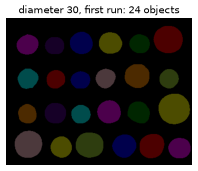

In [17]:
show(images[0], "diameter 30, first run")